# LeetCode #42: Trapping Rain Water

https://leetcode.com/problems/trapping-rain-water/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(1)$ |
| **Prefix Max Arrays** | $O(n)$ | $O(n)$ |
| **Two Pointers** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
For each index `i`, scan left to find `leftMax` and right to find `rightMax`. Water at `i` = `min(leftMax, rightMax) - height[i]`. $O(n)$ per position = $O(n^2)$ total.

### Prefix Max Arrays
Precompute `leftMax[i]` = max height from 0..i and `rightMax[i]` = max height from i..n-1. Then `water = sum of min(leftMax[i], rightMax[i]) - height[i]`. $O(n)$ time but $O(n)$ extra space.

### Optimal: Two Pointers ★
Maintain `left`, `right` pointers at both ends, and `leftMax`, `rightMax` running maximums. At each step, the pointer whose max is smaller advances — because water at that position is bounded by its max (the other side is guaranteed to be at least as tall). Single pass, $O(1)$ space.

**Key insight:** Water at position `i` = `min(leftMax, rightMax) - height[i]`. When `leftMax <= rightMax`, the limit is `leftMax` regardless of the right side, so we can safely compute and advance left.

**Constraints:**
* $n$ == height.length
* $1 \leq n \leq 2 \times 10^4$
* $0 \leq$ height[i] $\leq 10^5$

## Solutions

### C#

In [ ]:
public class Solution {
    public int Trap(int[] height) {
        int left = 0, right = height.Length - 1;
        int leftMax = 0, rightMax = 0, water = 0;
        while (left < right) {
            if (height[left] <= height[right]) {
                leftMax = Math.Max(leftMax, height[left]);
                water += leftMax - height[left];
                left++;
            } else {
                rightMax = Math.Max(rightMax, height[right]);
                water += rightMax - height[right];
                right--;
            }
        }
        return water;
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def trap(self, height: List[int]) -> int:
        left, right = 0, len(height) - 1
        left_max = right_max = water = 0
        while left < right:
            if height[left] <= height[right]:
                left_max = max(left_max, height[left])
                water += left_max - height[left]
                left += 1
            else:
                right_max = max(right_max, height[right])
                water += right_max - height[right]
                right -= 1
        return water

### Go

In [ ]:
package main

func trap(height []int) int {
	left, right := 0, len(height)-1
	leftMax, rightMax, water := 0, 0, 0
	for left < right {
		if height[left] <= height[right] {
			if height[left] > leftMax {
				leftMax = height[left]
			}
			water += leftMax - height[left]
			left++
		} else {
			if height[right] > rightMax {
				rightMax = height[right]
			}
			water += rightMax - height[right]
			right--
		}
	}
	return water
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn trap(height: Vec<i32>) -> i32 {
        let (mut left, mut right) = (0usize, height.len() - 1);
        let (mut left_max, mut right_max, mut water) = (0i32, 0i32, 0i32);
        while left < right {
            if height[left] <= height[right] {
                left_max = left_max.max(height[left]);
                water += left_max - height[left];
                left += 1;
            } else {
                right_max = right_max.max(height[right]);
                water += right_max - height[right];
                right -= 1;
            }
        }
        water
    }
}

## Example Scenarios

### 1. Common Case — Classic Rain Water
**Input:** `[0,1,0,2,1,0,1,3,2,1,2,1]`
Two pointers start at ends. Left pointer advances when `height[left] < height[right]`. At each step: if current height < leftMax (or rightMax), water += difference. Water accumulates at indices 2(1), 4(1), 5(2), 6(1), 9(1) = 6 total.
**Why tricky:** The textbook example. Interviewers expect you to trace through it fluently. The key insight: water at any position = $\min(\text{leftMax}, \text{rightMax}) - \text{height}[i]$.

**Output:** `6`

### 2. Slightly Complex — Wide Basin Between Tall Walls
**Input:** `[4, 2, 0, 3, 2, 5]`
Left wall = 4, right wall = 5. Water at each inner position: index 1: $\min(4,5)-2=2$, index 2: $\min(4,5)-0=4$, index 3: $\min(4,5)-3=1$, index 4: $\min(4,5)-2=2$. Total = 9.
**Why tricky:** The bottleneck is the shorter wall (4). All inner positions are below it, so every position contributes water. Tests understanding that water level = min of the two max walls.

**Output:** `9`

### 3. Edge Case: Time Factor — Alternating Heights (n = 2×10⁴)
**Input:** `[10⁵, 0, 10⁵, 0, ..., 10⁵, 0]` — 20,000 elements alternating max height and zero
Each zero-height position traps $10^5$ units. 10,000 zeros → total water = $10^9$. Two pointers: single $O(n)$ pass.
**Why tricky:** Brute force $O(n^2) = 4 \times 10^8$ is borderline TLE. Two pointers stays $O(n)$ regardless of height values. Result ($10^9$) fits in a 32-bit signed int ($2^{31} - 1 \approx 2.1 \times 10^9$), but just barely — interviewers may probe overflow awareness.

**Output:** $10^9$ — $O(n)$ time, $O(1)$ space.

### 4. Edge Case: Space Factor — Monotonically Increasing (No Water)
**Input:** `[1, 2, 3, 4, 5]`
Every bar is taller than all bars to its left. leftMax always equals the current height, so water = leftMax - height = 0 everywhere. Two pointers finish in $O(n)$ with $O(1)$ space.
**Why tricky:** The prefix-max approach allocates two $O(n)$ arrays that contribute nothing. Two pointers use $O(1)$ space regardless. This case highlights the space advantage.

**Output:** `0`

### 5. Almost-Impossible but Plausible — All Bars at Maximum Height
**Input:** `[10⁵, 10⁵, ..., 10⁵]` — 20,000 elements, all $10^5$
At every position: $\min(\text{leftMax}, \text{rightMax}) - \text{height}[i] = 10^5 - 10^5 = 0$. A perfectly flat surface traps nothing.
**Why tricky:** Maximum constraint values ($h = 10^5$, $n = 2 \times 10^4$) producing zero output. Tests for subtle overflow: leftMax + rightMax could reach $2 \times 10^5$, but the algorithm only uses $\min$, so no overflow risk. An edge case that looks trivial but validates boundary arithmetic.

**Output:** `0`

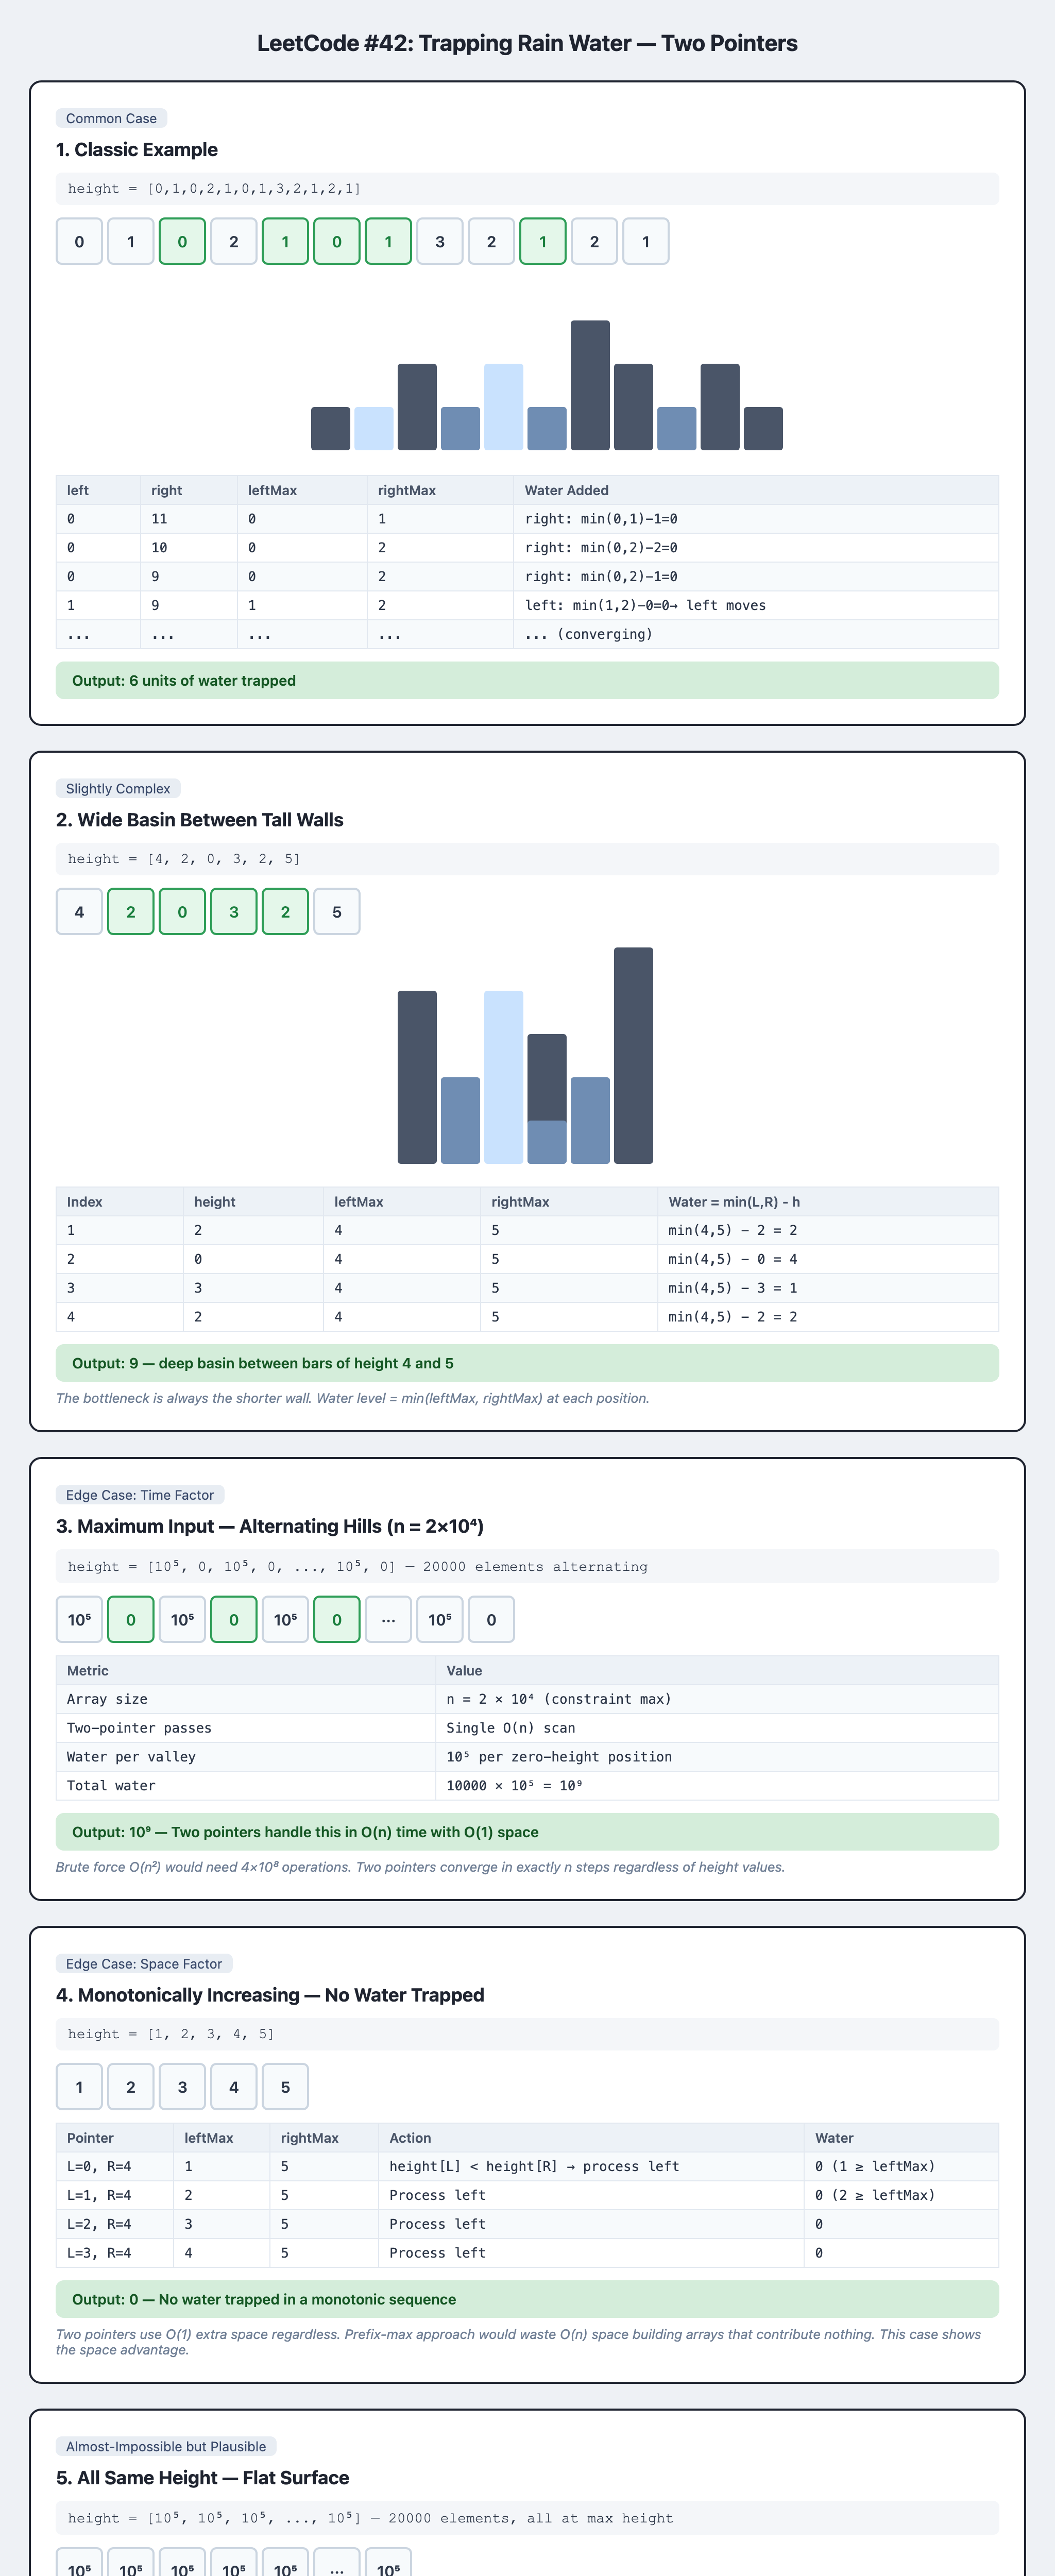